<a href="https://colab.research.google.com/github/ArthTechX/Diffusion-Language-Models/blob/main/week1_proper_lora_vs_dg_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 — Proper LoRA vs DG+LoRA Reproducibility Run

This notebook fixes the earlier Week 1 scaffold. It runs a matched **LoRA** vs **DG+LoRA** experiment on one small toy domain using `inclusionAI/LLaDA-MoE-7B-A1B-Instruct` on free Colab T4.

Now covered for Week 1:
- LoRA baseline with trainable low-rank branches.
- DG+LoRA with real frozen branch + trainable LoRA branch + noise/timestep gate.
- Per-timestep/noise-bin losses.
- Real DG gate entropy.
- Real frozen/trainable branch usage.
- Teacher agreement against frozen-base path.
- GPU memory logging.
- Matched baseline table + reproducibility JSON.

Note: this is a minimal runnable DG+LoRA implementation for Colab. It implements actual gated branches inside selected linear modules, but it is not a byte-for-byte reproduction of the private/submitted DiffusionGrow repository.

## 0. GPU check

In [11]:
!nvidia-smi

Fri Jul  3 08:42:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies
Run this cell, then restart runtime: **Runtime → Restart session**. After restart, continue from Section 2.

In [12]:
!pip uninstall -y transformers tokenizers -q

!pip -q install --no-cache-dir \
  "transformers>=4.45.0,<5.0.0" \
  "bitsandbytes>=0.46.1" \
  accelerate \
  safetensors \
  sentencepiece \
  einops \
  huggingface_hub \
  pandas \
  matplotlib \
  numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 218.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 286.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 454.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 356.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports and configuration

In [1]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc, json, math, time, random
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32

# Safe for free Colab T4. Increase to [15,14] only after this works.
SELECTED_LAYERS = [15]

LORA_RANK = 4
LORA_ALPHA = 8
LORA_DROPOUT = 0.05
TRAIN_STEPS = 5
LR = 2e-4
LAMBDA_RET = 0.5
BETA_GATE = 0.05

NOISE_BINS = {"low_noise": 0.15, "mid_noise": 0.50, "high_noise": 0.85}
NOISE_BIN_TO_IDX = {"low_noise": 0, "mid_noise": 1, "high_noise": 2}

TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "for i in range(n): total += arr[i]",
    "A binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]
RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

OUT_DIR = Path("/content/week1_proper_dg_lora")
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output dir:", OUT_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Output dir: /content/week1_proper_dg_lora
GPU: Tesla T4


## 3. Load tokenizer

In [2]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("Tokenizer loaded:", MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Tokenizer loaded: inclusionAI/LLaDA-MoE-7B-A1B-Instruct


## 4. Load base model helper

In [3]:
def cleanup_model():
    global model
    try:
        del model
    except Exception:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_base_model():
    cleanup_model()
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={0: "13GiB", "cpu": "25GiB"},
        low_cpu_mem_usage=True,
    )
    base.eval()
    return base


def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass
    if hasattr(model, "device"):
        return model.device
    for p in model.parameters():
        return p.device
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def gpu_mem_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 5. Token masking and loss helpers

In [5]:
def encode_text(text, model):
    input_device = get_input_device(model)
    batch = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    input_ids = batch["input_ids"].to(input_device)
    attention_mask = batch.get("attention_mask", torch.ones_like(input_ids)).to(input_device)
    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()
    masked_indices = (rand < mask_prob) & valid
    if not masked_indices.any():
        masked_indices[0, -1] = True
    noisy_ids = torch.where(masked_indices, torch.full_like(clean_ids, MASK_ID), clean_ids)
    return noisy_ids, masked_indices


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits
    if isinstance(out, (tuple, list)):
        return out[0]
    return out


def forward_logits(model, input_ids):
    out = model(input_ids=input_ids)
    return get_logits_from_output(out)


def masked_weighted_ce(logits, labels, masked_indices, mask_prob):
    if masked_indices.sum().item() == 0:
        zero = torch.tensor(0.0, device=logits.device)
        return zero, zero
    logits_m = logits[masked_indices].float()
    labels_m = labels[masked_indices]
    ce = F.cross_entropy(logits_m, labels_m)
    weighted = ce / mask_prob
    return weighted, ce


def teacher_agreement(student_logits, teacher_logits, masked_indices):
    if masked_indices.sum().item() == 0:
        return float("nan")
    student_pred = student_logits.argmax(dim=-1)
    teacher_pred = teacher_logits.argmax(dim=-1)
    return (student_pred[masked_indices] == teacher_pred[masked_indices]).float().mean().item()

## 6. Real DG+LoRA gated linear module

In [6]:
class DGGatedLoRALinear(nn.Module):
    """
    Minimal real DG+LoRA / LoRA branch wrapper.

    gate_mode="lora": deterministic LoRA baseline, alpha_grown = 1.
    gate_mode="dg": DG+LoRA, alpha_grown = sigmoid(gate_logits[noise_bin]).
    """
    def __init__(self, base_layer, r=4, lora_alpha=8, lora_dropout=0.05, gate_mode="dg"):
        super().__init__()
        if not hasattr(base_layer, "in_features") or not hasattr(base_layer, "out_features"):
            raise ValueError("Base layer must expose in_features and out_features.")
        self.base_layer = base_layer
        self.in_features = int(base_layer.in_features)
        self.out_features = int(base_layer.out_features)
        self.r = int(r)
        self.scaling = float(lora_alpha) / float(r)
        self.gate_mode = gate_mode
        for p in self.base_layer.parameters():
            p.requires_grad = False
        try:
            device = base_layer.weight.device
        except Exception:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.lora_A = nn.Linear(self.in_features, self.r, bias=False).to(device=device, dtype=torch.float32)
        self.lora_B = nn.Linear(self.r, self.out_features, bias=False).to(device=device, dtype=torch.float32)
        self.dropout = nn.Dropout(lora_dropout)
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)
        # low/mid/high initial grown usage: ~0.38 / 0.27 / 0.12
        init_logits = torch.tensor([-0.5, -1.0, -2.0], device=device, dtype=torch.float32)
        if gate_mode == "dg":
            self.gate_logits = nn.Parameter(init_logits)
        else:
            self.register_buffer("gate_logits", init_logits, persistent=False)
        self.register_buffer("noise_bin_idx", torch.tensor(0, dtype=torch.long, device=device), persistent=False)
        self.adapter_disabled = False

    def set_noise_bin_idx(self, idx):
        self.noise_bin_idx.fill_(int(idx))

    def alpha_grown_tensor(self):
        if self.adapter_disabled:
            return torch.zeros((), device=self.noise_bin_idx.device, dtype=torch.float32)
        if self.gate_mode == "lora":
            return torch.ones((), device=self.noise_bin_idx.device, dtype=torch.float32)
        idx = int(self.noise_bin_idx.item())
        return torch.sigmoid(self.gate_logits[idx])

    def gate_entropy_tensor(self, eps=1e-8):
        if self.gate_mode == "lora":
            return torch.zeros((), device=self.noise_bin_idx.device, dtype=torch.float32)
        a = self.alpha_grown_tensor().clamp(eps, 1.0 - eps)
        probs = torch.stack([1.0 - a, a])
        return -(probs * torch.log(probs)).sum()

    def frozen_usage_tensor(self):
        return 1.0 - self.alpha_grown_tensor()

    def trainable_usage_tensor(self):
        return self.alpha_grown_tensor()

    def forward(self, x, *args, **kwargs):
        frozen_out = self.base_layer(x, *args, **kwargs)
        if self.adapter_disabled:
            return frozen_out
        x_lora = x.to(self.lora_A.weight.dtype)
        delta = self.lora_B(self.lora_A(self.dropout(x_lora))) * self.scaling
        delta = delta.to(frozen_out.dtype)
        alpha = self.alpha_grown_tensor().to(frozen_out.dtype)
        return frozen_out + alpha * delta


def iter_dg_lora_modules(model):
    for module in model.modules():
        if isinstance(module, DGGatedLoRALinear):
            yield module


def set_noise_bin(model, noise_bin):
    idx = NOISE_BIN_TO_IDX[noise_bin]
    for module in iter_dg_lora_modules(model):
        module.set_noise_bin_idx(idx)


@contextmanager
def disable_adapters(model):
    modules = list(iter_dg_lora_modules(model))
    old_values = [m.adapter_disabled for m in modules]
    try:
        for m in modules:
            m.adapter_disabled = True
        yield
    finally:
        for m, old in zip(modules, old_values):
            m.adapter_disabled = old


def gate_regularizer_tensor(model, method, eps=1e-8):
    modules = list(iter_dg_lora_modules(model))
    if method != "dg_lora" or len(modules) == 0:
        return torch.tensor(0.0, device=get_input_device(model))
    vals = []
    for m in modules:
        a_grown = m.trainable_usage_tensor().clamp(eps, 1.0 - eps)
        a_frozen = (1.0 - a_grown).clamp(eps, 1.0 - eps)
        vals.append(-torch.log(a_frozen))
    return torch.stack(vals).mean()


@torch.no_grad()
def collect_gate_metrics(model):
    modules = list(iter_dg_lora_modules(model))
    if not modules:
        return {"gate_entropy": float("nan"), "frozen_branch_usage": float("nan"), "trainable_branch_usage": float("nan"), "num_gated_modules": 0}
    ent, frozen, grown = [], [], []
    for m in modules:
        ent.append(float(m.gate_entropy_tensor().detach().cpu()))
        frozen.append(float(m.frozen_usage_tensor().detach().cpu()))
        grown.append(float(m.trainable_usage_tensor().detach().cpu()))
    return {"gate_entropy": float(np.mean(ent)), "frozen_branch_usage": float(np.mean(frozen)), "trainable_branch_usage": float(np.mean(grown)), "num_gated_modules": len(modules)}

## 7. Find and replace selected modules

In [7]:
def extract_layer_id(module_name):
    parts = module_name.split(".")
    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"]:
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                return int(parts[i + 1])
    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 200:
                return value
    return None


def find_linear_modules_for_layers(model, selected_layers):
    selected_layers = set(selected_layers)
    preferred_leaf_names = {"q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"}
    target_names = []
    for name, module in model.named_modules():
        if name == "":
            continue
        cls_name = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]
        layer_id = extract_layer_id(name)
        is_linear_like = "linear" in cls_name and hasattr(module, "in_features") and hasattr(module, "out_features")
        if is_linear_like and layer_id in selected_layers and leaf in preferred_leaf_names:
            target_names.append(name)
    return sorted(target_names)


def get_child(parent, key):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        return parent[int(key)]
    return getattr(parent, key)


def set_child(parent, key, value):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        parent[int(key)] = value
    else:
        setattr(parent, key, value)


def get_parent_and_key(root, module_name):
    parts = module_name.split(".")
    parent = root
    for p in parts[:-1]:
        parent = get_child(parent, p)
    return parent, parts[-1]


def attach_lora_or_dg_lora(model, method, selected_layers):
    assert method in ["lora", "dg_lora"]
    for p in model.parameters():
        p.requires_grad = False
    target_names = find_linear_modules_for_layers(model, selected_layers)
    if len(target_names) == 0:
        print("No target modules found. Showing first 80 linear-like modules:")
        shown = 0
        for name, module in model.named_modules():
            cls_name = module.__class__.__name__.lower()
            if "linear" in cls_name and hasattr(module, "in_features") and hasattr(module, "out_features"):
                print(name, "->", module.__class__.__name__)
                shown += 1
                if shown >= 80:
                    break
        raise RuntimeError("No selected linear modules found. Change SELECTED_LAYERS after inspecting names.")
    gate_mode = "lora" if method == "lora" else "dg"
    for name in target_names:
        parent, key = get_parent_and_key(model, name)
        old_module = get_child(parent, key)
        wrapped = DGGatedLoRALinear(old_module, r=LORA_RANK, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT, gate_mode=gate_mode)
        set_child(parent, key, wrapped)
    return target_names

# Quick inspection. This should print target modules before full run.
inspect_model = load_base_model()
target_names = find_linear_modules_for_layers(inspect_model, SELECTED_LAYERS)
print("Selected layers:", SELECTED_LAYERS)
print("Found target modules:", len(target_names))
for x in target_names[:30]:
    print(x)
cleanup_model()

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.72G [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Selected layers: [15]
Found target modules: 196
model.layers.15.mlp.experts.0.down_proj
model.layers.15.mlp.experts.0.gate_proj
model.layers.15.mlp.experts.0.up_proj
model.layers.15.mlp.experts.1.down_proj
model.layers.15.mlp.experts.1.gate_proj
model.layers.15.mlp.experts.1.up_proj
model.layers.15.mlp.experts.10.down_proj
model.layers.15.mlp.experts.10.gate_proj
model.layers.15.mlp.experts.10.up_proj
model.layers.15.mlp.experts.11.down_proj
model.layers.15.mlp.experts.11.gate_proj
model.layers.15.mlp.experts.11.up_proj
model.layers.15.mlp.experts.12.down_proj
model.layers.15.mlp.experts.12.gate_proj
model.layers.15.mlp.experts.12.up_proj
model.layers.15.mlp.experts.13.down_proj
model.layers.15.mlp.experts.13.gate_proj
model.layers.15.mlp.experts.13.up_proj
model.layers.15.mlp.experts.14.down_proj
model.layers.15.mlp.experts.14.gate_proj
model.layers.15.mlp.experts.14.up_proj
model.layers.15.mlp.experts.15.down_proj
model.layers.15.mlp.experts.15.gate_proj
model.layers.15.mlp.experts.1

## 8. Training and evaluation functions

In [8]:
def compute_target_loss(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
    logits = forward_logits(model, noisy_ids)
    weighted_loss, ce_loss = masked_weighted_ce(logits, input_ids, masked_indices, mask_prob)
    return weighted_loss, ce_loss, int(masked_indices.sum().item())


def compute_retention_kl(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]
    set_noise_bin(model, noise_bin)
    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
    with torch.no_grad():
        with disable_adapters(model):
            teacher_logits = forward_logits(model, noisy_ids).float()
    student_logits = forward_logits(model, noisy_ids).float()
    if masked_indices.sum().item() == 0:
        return torch.tensor(0.0, device=get_input_device(model)), 0
    teacher_log_probs = F.log_softmax(teacher_logits[masked_indices], dim=-1)
    student_log_probs = F.log_softmax(student_logits[masked_indices], dim=-1)
    teacher_probs = teacher_log_probs.exp()
    kl = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") / mask_prob
    return kl, int(masked_indices.sum().item())


def train_one_method(model, method):
    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    rows = []
    for step in range(TRAIN_STEPS):
        noise_bin = random.choice(list(NOISE_BINS.keys()))
        mask_prob = NOISE_BINS[noise_bin]
        target_text = random.choice(TARGET_TEXTS)
        retention_text = random.choice(RETENTION_TEXTS)
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
        start = time.time()
        target_loss, target_ce, target_masked = compute_target_loss(model, target_text, noise_bin)
        retention_kl, retention_masked = compute_retention_kl(model, retention_text, noise_bin)
        gate_reg = gate_regularizer_tensor(model, method)
        total_loss = target_loss + LAMBDA_RET * retention_kl + BETA_GATE * gate_reg
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        elapsed = time.time() - start
        gm = collect_gate_metrics(model)
        row = {
            "method": method, "phase": "train", "step": step, "noise_bin": noise_bin, "mask_prob": mask_prob,
            "target_text": target_text, "retention_text": retention_text,
            "target_ce_loss": float(target_ce.detach().cpu()), "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()), "gate_regularizer": float(gate_reg.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()), "target_masked_tokens": target_masked, "retention_masked_tokens": retention_masked,
            "gate_entropy": gm["gate_entropy"], "frozen_branch_usage": gm["frozen_branch_usage"],
            "trainable_branch_usage": gm["trainable_branch_usage"], "num_gated_modules": gm["num_gated_modules"],
            "trainable_params": count_trainable_params(model), "peak_gpu_memory_gb": gpu_mem_gb(), "elapsed_sec": elapsed,
        }
        rows.append(row); print(row)
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    return rows


@torch.no_grad()
def eval_one_method(model, method, phase):
    model.eval()
    rows = []
    eval_sets = [("target_code_toy", TARGET_TEXTS), ("retention_general_toy", RETENTION_TEXTS)]
    for domain, texts in eval_sets:
        for text in texts:
            for noise_bin, mask_prob in NOISE_BINS.items():
                set_noise_bin(model, noise_bin)
                input_ids, attention_mask = encode_text(text, model)
                noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)
                if torch.cuda.is_available():
                    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
                start = time.time()
                student_logits = forward_logits(model, noisy_ids).float()
                with disable_adapters(model):
                    teacher_logits = forward_logits(model, noisy_ids).float()
                elapsed = time.time() - start
                student_weighted, student_ce = masked_weighted_ce(student_logits, input_ids, masked_indices, mask_prob)
                teacher_weighted, teacher_ce = masked_weighted_ce(teacher_logits, input_ids, masked_indices, mask_prob)
                agree = teacher_agreement(student_logits, teacher_logits, masked_indices)
                gm = collect_gate_metrics(model)
                rows.append({
                    "method": method, "phase": phase, "domain": domain, "text": text, "noise_bin": noise_bin, "mask_prob": mask_prob,
                    "ce_loss": float(student_ce.detach().cpu()), "weighted_loss": float(student_weighted.detach().cpu()),
                    "teacher_ce_loss": float(teacher_ce.detach().cpu()), "teacher_weighted_loss": float(teacher_weighted.detach().cpu()),
                    "forgetting_vs_pretrained": float((student_weighted - teacher_weighted).detach().cpu()),
                    "teacher_agreement": agree, "masked_tokens": int(masked_indices.sum().item()),
                    "gate_entropy": gm["gate_entropy"], "frozen_branch_usage": gm["frozen_branch_usage"],
                    "trainable_branch_usage": gm["trainable_branch_usage"], "num_gated_modules": gm["num_gated_modules"],
                    "trainable_params": count_trainable_params(model), "peak_gpu_memory_gb": gpu_mem_gb(), "elapsed_sec": elapsed,
                })
                if torch.cuda.is_available(): torch.cuda.empty_cache()
    return rows

## 9. Run matched LoRA and DG+LoRA experiments

In [9]:
all_train_rows = []
all_eval_rows = []
method_meta = []

for method in ["lora", "dg_lora"]:
    print("=" * 100)
    print("Starting method:", method)
    cleanup_model()
    model = load_base_model()
    target_modules = attach_lora_or_dg_lora(model, method=method, selected_layers=SELECTED_LAYERS)
    print("Attached modules:", len(target_modules))
    print("Trainable params:", count_trainable_params(model))
    print("Memory footprint GB:", model.get_memory_footprint() / 1024**3)
    method_meta.append({
        "method": method,
        "selected_layers": SELECTED_LAYERS,
        "target_modules": target_modules,
        "num_target_modules": len(target_modules),
        "trainable_params": count_trainable_params(model),
        "lora_rank": LORA_RANK,
        "lora_alpha": LORA_ALPHA,
        "lambda_ret": LAMBDA_RET,
        "beta_gate": BETA_GATE if method == "dg_lora" else 0.0,
    })
    before_rows = eval_one_method(model, method, phase="before")
    train_rows = train_one_method(model, method)
    after_rows = eval_one_method(model, method, phase="after")
    all_eval_rows.extend(before_rows); all_eval_rows.extend(after_rows); all_train_rows.extend(train_rows)
    pd.DataFrame(all_eval_rows).to_csv(OUT_DIR / "week1_eval_partial.csv", index=False)
    pd.DataFrame(all_train_rows).to_csv(OUT_DIR / "week1_train_partial.csv", index=False)
    print("Partial files saved.")
    cleanup_model()

eval_df = pd.DataFrame(all_eval_rows)
train_df = pd.DataFrame(all_train_rows)

eval_path = OUT_DIR / "week1_lora_vs_dg_lora_eval_log.csv"
train_path = OUT_DIR / "week1_lora_vs_dg_lora_train_log.csv"
meta_path = OUT_DIR / "week1_method_meta.json"
eval_df.to_csv(eval_path, index=False)
train_df.to_csv(train_path, index=False)
with open(meta_path, "w") as f:
    json.dump(method_meta, f, indent=2)
print("Saved:", eval_path)
print("Saved:", train_path)
print("Saved:", meta_path)
display(eval_df.head())
display(train_df.head())

Starting method: lora


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Attached modules: 196
Trainable params: 2424832
Memory footprint GB: 4.3343659192323685


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'method': 'lora', 'phase': 'train', 'step': 0, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'target_text': 'def add_numbers(a, b): return a + b', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 7.691159248352051, 'target_weighted_loss': 9.048422813415527, 'retention_kl_loss': 3.3317326142423553e-07, 'gate_regularizer': 0.0, 'total_loss': 9.048422813415527, 'target_masked_tokens': 10, 'retention_masked_tokens': 6, 'gate_entropy': 0.0, 'frozen_branch_usage': 0.0, 'trainable_branch_usage': 1.0, 'num_gated_modules': 196, 'trainable_params': 2424832, 'peak_gpu_memory_gb': 8.922363758087158, 'elapsed_sec': 2.790074110031128}
{'method': 'lora', 'phase': 'train', 'step': 1, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'target_text': 'A binary search repeatedly halves the search interval.', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 4.315999507904053, 'target_weighted_loss': 5.077646732330322, 'retention_kl_loss': 1.8613869542605

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Attached modules: 196
Trainable params: 2425420
Memory footprint GB: 4.3343659192323685
{'method': 'dg_lora', 'phase': 'train', 'step': 0, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'target_text': 'def add_numbers(a, b): return a + b', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 0.0662260428071022, 'target_weighted_loss': 0.441506952047348, 'retention_kl_loss': 0.0, 'gate_regularizer': 0.474077045917511, 'total_loss': 0.46521079540252686, 'target_masked_tokens': 1, 'retention_masked_tokens': 1, 'gate_entropy': 0.6628239750862122, 'frozen_branch_usage': 0.6225060820579529, 'trainable_branch_usage': 0.3774939179420471, 'num_gated_modules': 196, 'trainable_params': 2425420, 'peak_gpu_memory_gb': 8.92273759841919, 'elapsed_sec': 2.870793581008911}
{'method': 'dg_lora', 'phase': 'train', 'step': 1, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'target_text': 'class Queue: def __init__(self): self.items = []', 'retention_text': 'A healthy diet includes fruit

,method,phase,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,teacher_ce_loss,teacher_weighted_loss,forgetting_vs_pretrained,teacher_agreement,masked_tokens,gate_entropy,frozen_branch_usage,trainable_branch_usage,num_gated_modules,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,lora,before,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,2.872661,19.151072,2.872661,19.151072,0.0,1.0,3,0.0,0.0,1.0,196,2424832,8.894694,2.624625
1,lora,before,target_code_toy,"def add_numbers(a, b): return a + b",mid_noise,0.50,0.668566,1.337132,0.668566,1.337132,0.0,1.0,5,0.0,0.0,1.0,196,2424832,8.900842,1.957873
2,lora,before,target_code_toy,"def add_numbers(a, b): return a + b",high_noise,0.85,7.790171,9.164907,7.790171,9.164907,0.0,1.0,9,0.0,0.0,1.0,196,2424832,8.901721,1.859044
3,lora,before,target_code_toy,for i in range(n): total += arr[i],low_noise,0.15,1.975544,13.170296,1.975544,13.170296,0.0,1.0,1,0.0,0.0,1.0,196,2424832,8.900842,1.615093
4,lora,before,target_code_toy,for i in range(n): total += arr[i],mid_noise,0.50,3.827152,7.654305,3.827152,7.654305,0.0,1.0,7,0.0,0.0,1.0,196,2424832,8.900842,1.662848


,method,phase,step,noise_bin,mask_prob,target_text,retention_text,target_ce_loss,target_weighted_loss,retention_kl_loss,...,total_loss,target_masked_tokens,retention_masked_tokens,gate_entropy,frozen_branch_usage,trainable_branch_usage,num_gated_modules,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,lora,train,0,high_noise,0.85,"def add_numbers(a, b): return a + b",The city library opens every morning.,7.691159,9.048423,3.331733e-07,...,9.048423,10,6,0.0,0.0,1.0,196,2424832,8.922364,2.790074
1,lora,train,1,high_noise,0.85,A binary search repeatedly halves the search i...,The city library opens every morning.,4.316000,5.077647,1.861387e-05,...,5.077656,5,6,0.0,0.0,1.0,196,2424832,8.951863,2.526958
2,lora,train,2,low_noise,0.15,for i in range(n): total += arr[i],"A healthy diet includes fruits, vegetables, gr...",1.439166,9.594442,1.489238e-03,...,9.595187,3,1,0.0,0.0,1.0,196,2424832,8.945288,2.973472
3,lora,train,3,low_noise,0.15,class Queue: def __init__(self): self.items = [],The city library opens every morning.,1.764495,11.763302,7.213792e-05,...,11.763338,1,1,0.0,0.0,1.0,196,2424832,8.933488,3.425070
4,lora,train,4,high_noise,0.85,The function computes the maximum subarray sum...,The city library opens every morning.,3.523717,4.145549,1.919488e-05,...,4.145559,9,6,0.0,0.0,1.0,196,2424832,8.955334,2.539553


## 10. Matched baseline table

In [10]:
after_df = eval_df[eval_df["phase"] == "after"].copy()
matched_table = (
    after_df.groupby(["method", "domain"])
    .agg(
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_ce_loss=("ce_loss", "mean"),
        mean_forgetting_vs_pretrained=("forgetting_vs_pretrained", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        mean_gate_entropy=("gate_entropy", "mean"),
        mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
        mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
        trainable_params=("trainable_params", "max"),
        num_gated_modules=("num_gated_modules", "max"),
    )
    .reset_index()
)
matched_table_path = OUT_DIR / "week1_matched_baseline_table.csv"
matched_table.to_csv(matched_table_path, index=False)
print("Saved:", matched_table_path)
display(matched_table)

Saved: /content/week1_proper_dg_lora/week1_matched_baseline_table.csv


,method,domain,mean_weighted_loss,mean_ce_loss,mean_forgetting_vs_pretrained,mean_teacher_agreement,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage,max_gpu_memory_gb,trainable_params,num_gated_modules
0,dg_lora,retention_general_toy,13.925016,5.371158,-0.002873,1.000000,0.536748,0.744846,0.255154,8.926980,2425420,196
1,dg_lora,target_code_toy,9.417342,4.274562,-0.015332,1.000000,0.536748,0.744846,0.255154,8.924638,2425420,196
2,lora,retention_general_toy,15.171968,5.837062,-0.002990,0.962963,0.000000,0.000000,1.000000,8.925716,2424832,196
3,lora,target_code_toy,8.150670,3.863830,-0.065237,1.000000,0.000000,0.000000,1.000000,8.921908,2424832,196


## 11. Per-noise-bin / per-timestep table

In [11]:
noise_table = (
    after_df.groupby(["method", "domain", "noise_bin"])
    .agg(
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        mean_gate_entropy=("gate_entropy", "mean"),
        mean_frozen_branch_usage=("frozen_branch_usage", "mean"),
        mean_trainable_branch_usage=("trainable_branch_usage", "mean"),
        mean_masked_tokens=("masked_tokens", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
    )
    .reset_index()
)
noise_table_path = OUT_DIR / "week1_per_timestep_noise_table.csv"
noise_table.to_csv(noise_table_path, index=False)
print("Saved:", noise_table_path)
display(noise_table)

Saved: /content/week1_proper_dg_lora/week1_per_timestep_noise_table.csv


,method,domain,noise_bin,mean_weighted_loss,mean_teacher_agreement,mean_gate_entropy,mean_frozen_branch_usage,mean_trainable_branch_usage,mean_masked_tokens,max_gpu_memory_gb
0,dg_lora,retention_general_toy,high_noise,8.999873,1.000000,0.365296,0.880816,0.119184,10.666667,8.926980
1,dg_lora,retention_general_toy,low_noise,22.640017,1.000000,0.662744,0.622666,0.377334,2.000000,8.922880
2,dg_lora,retention_general_toy,mid_noise,10.135157,1.000000,0.582205,0.731057,0.268943,6.333333,8.924051
3,dg_lora,target_code_toy,high_noise,8.744175,1.000000,0.365296,0.880816,0.119184,9.800000,8.924638
4,dg_lora,target_code_toy,low_noise,12.465111,1.000000,0.662744,0.622666,0.377334,1.400000,8.921416
5,dg_lora,target_code_toy,mid_noise,7.042739,1.000000,0.582205,0.731057,0.268943,5.400000,8.922002
6,lora,retention_general_toy,high_noise,10.650665,1.000000,0.000000,0.000000,1.000000,10.000000,8.925716
7,lora,retention_general_toy,low_noise,25.641428,0.888889,0.000000,0.000000,1.000000,1.666667,8.922787
8,lora,retention_general_toy,mid_noise,9.223812,1.000000,0.000000,0.000000,1.000000,5.666667,8.923958
9,lora,target_code_toy,high_noise,8.356061,1.000000,0.000000,0.000000,1.000000,9.400000,8.921908


## 12. Plots

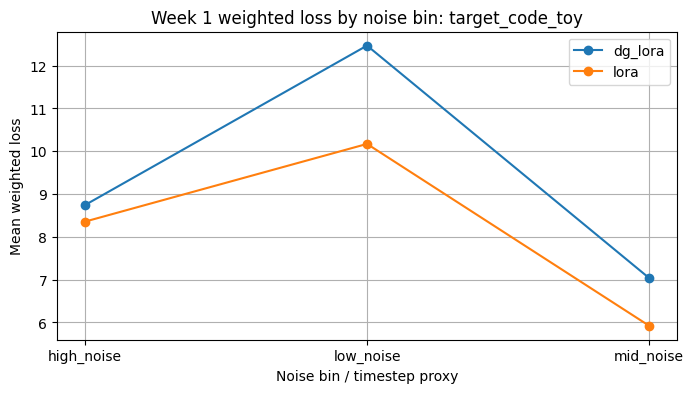

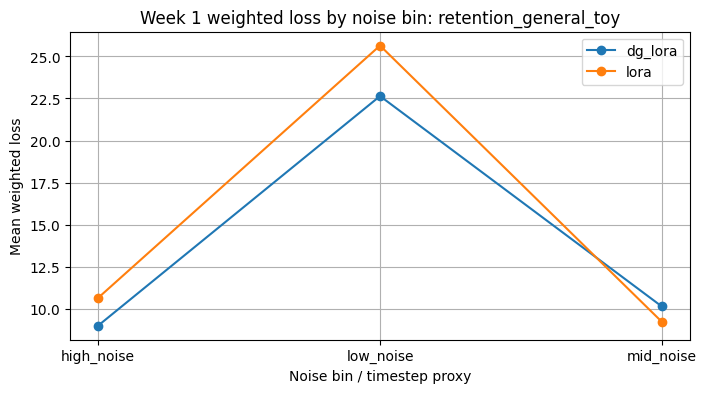

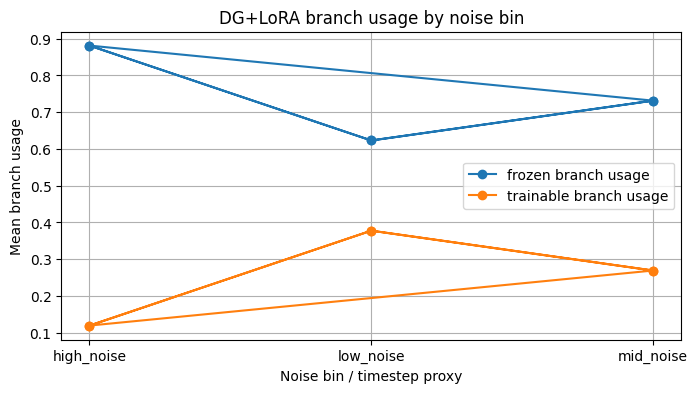

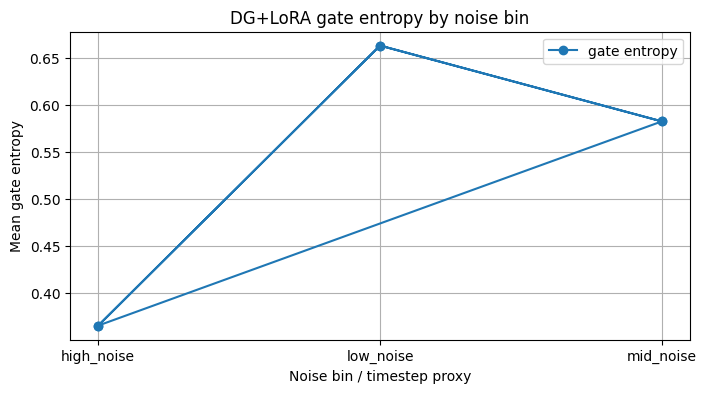

In [12]:
for domain in after_df["domain"].unique():
    sub = noise_table[noise_table["domain"] == domain].copy()
    plt.figure(figsize=(8, 4))
    for method in sub["method"].unique():
        s = sub[sub["method"] == method]
        plt.plot(s["noise_bin"], s["mean_weighted_loss"], marker="o", label=method)
    plt.title(f"Week 1 weighted loss by noise bin: {domain}")
    plt.xlabel("Noise bin / timestep proxy")
    plt.ylabel("Mean weighted loss")
    plt.legend(); plt.grid(True); plt.show()

dg_sub = noise_table[noise_table["method"] == "dg_lora"].copy()
if len(dg_sub) > 0:
    plt.figure(figsize=(8, 4))
    plt.plot(dg_sub["noise_bin"], dg_sub["mean_frozen_branch_usage"], marker="o", label="frozen branch usage")
    plt.plot(dg_sub["noise_bin"], dg_sub["mean_trainable_branch_usage"], marker="o", label="trainable branch usage")
    plt.title("DG+LoRA branch usage by noise bin")
    plt.xlabel("Noise bin / timestep proxy")
    plt.ylabel("Mean branch usage")
    plt.legend(); plt.grid(True); plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(dg_sub["noise_bin"], dg_sub["mean_gate_entropy"], marker="o", label="gate entropy")
    plt.title("DG+LoRA gate entropy by noise bin")
    plt.xlabel("Noise bin / timestep proxy")
    plt.ylabel("Mean gate entropy")
    plt.legend(); plt.grid(True); plt.show()

## 13. Save reproducibility report

In [13]:
commands = [
    "Runtime -> Change runtime type -> GPU",
    "!nvidia-smi",
    "pip install transformers>=4.45.0,<5.0.0 bitsandbytes>=0.46.1 accelerate safetensors sentencepiece einops huggingface_hub pandas matplotlib numpy",
    "Load tokenizer with trust_remote_code=True",
    "Load model with 4-bit NF4 and device_map=auto",
    "Attach matched LoRA and DG+LoRA wrappers on SELECTED_LAYERS",
    "Train: target CE + lambda_ret * retention KL + beta_gate * gate regularizer",
    "Evaluate target and retention examples across low/mid/high noise bins",
]
commands_path = OUT_DIR / "week1_exact_commands.txt"
with open(commands_path, "w") as f:
    for cmd in commands:
        f.write(cmd + "\n")

report = {
    "week": 1,
    "task": "Reproduce matched LoRA and DG+LoRA runs on one small model/domain",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "quantization": "4-bit NF4",
    "max_length": MAX_LENGTH,
    "selected_layers": SELECTED_LAYERS,
    "lora_rank": LORA_RANK,
    "lora_alpha": LORA_ALPHA,
    "train_steps": TRAIN_STEPS,
    "lambda_ret": LAMBDA_RET,
    "beta_gate": BETA_GATE,
    "noise_bins": NOISE_BINS,
    "target_domain": "toy code examples",
    "retention_domain": "toy general examples",
    "outputs": {
        "eval_log": str(eval_path),
        "train_log": str(train_path),
        "method_meta": str(meta_path),
        "matched_baseline_table": str(matched_table_path),
        "per_timestep_noise_table": str(noise_table_path),
        "commands": str(commands_path),
    },
    "what_is_real": [
        "LoRA trainable low-rank branches",
        "DG+LoRA frozen branch plus trainable LoRA branch",
        "Noise-bin-conditioned trainable gate for DG+LoRA",
        "Gate entropy",
        "Frozen/trainable branch usage",
        "Teacher agreement via adapter-disabled frozen path",
        "Per-noise-bin/per-timestep losses",
    ],
    "limitation": "Minimal Colab implementation inside selected linear modules, not byte-for-byte private DiffusionGrow repository reproduction.",
}
report_path = OUT_DIR / "week1_reproducibility_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)
print("Saved:", report_path)
print("Saved:", commands_path)
print(json.dumps(report, indent=2))

Saved: /content/week1_proper_dg_lora/week1_reproducibility_report.json
Saved: /content/week1_proper_dg_lora/week1_exact_commands.txt
{
  "week": 1,
  "task": "Reproduce matched LoRA and DG+LoRA runs on one small model/domain",
  "model": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "gpu": "Tesla T4",
  "quantization": "4-bit NF4",
  "max_length": 32,
  "selected_layers": [
    15
  ],
  "lora_rank": 4,
  "lora_alpha": 8,
  "train_steps": 5,
  "lambda_ret": 0.5,
  "beta_gate": 0.05,
  "noise_bins": {
    "low_noise": 0.15,
    "mid_noise": 0.5,
    "high_noise": 0.85
  },
  "target_domain": "toy code examples",
  "retention_domain": "toy general examples",
  "outputs": {
    "eval_log": "/content/week1_proper_dg_lora/week1_lora_vs_dg_lora_eval_log.csv",
    "train_log": "/content/week1_proper_dg_lora/week1_lora_vs_dg_lora_train_log.csv",
    "method_meta": "/content/week1_proper_dg_lora/week1_method_meta.json",
    "matched_baseline_table": "/content/week1_proper_dg_lora/week1_matched_bas

## 14. Week 1 report paragraph

Use this after the run completes:

```text
Week 1 reproduced matched LoRA and DG+LoRA runs on a small LLaDA-family setup using inclusionAI/LLaDA-MoE-7B-A1B-Instruct on a free Colab T4 GPU with 4-bit NF4 loading. The LoRA baseline and DG+LoRA variant used the same selected layer set, LoRA rank, target-domain toy code examples, retention examples, noise bins, retention coefficient, and training steps. Unlike the earlier scaffold, DG+LoRA used a real frozen branch plus trainable LoRA branch with a noise-bin-conditioned gate, allowing actual logging of gate entropy and frozen/trainable branch usage. The run logged per-timestep/noise-bin target and retention losses, teacher agreement against the frozen-base path, forgetting relative to the pretrained path, GPU memory, trainable parameter counts, and exact command metadata. The outputs include a full evaluation log, training log, per-timestep table, matched baseline table, and reproducibility report.
```